# Using SeisCL within PyTorch

`SeisCL.torch` is an in-memory, CUDA-only binding that exposes SeisCL's forward-modeling and adjoint-gradient engine directly as a `torch.autograd`-differentiable operation. Unlike the main `SeisCL` class (which writes HDF5 files and launches the compiled `SeisCL_MPI` binary as a subprocess), `SeisCL.torch` calls straight into the compiled engine from the same Python process, exchanging data as `torch.Tensor`s -- no files, no subprocess.

This notebook shows how to:

1. Configure and run forward modeling with `SeisCL.torch`.
2. Compute the gradient of a loss with respect to model parameters via `torch.autograd`, exactly as with any other differentiable PyTorch operation -- the building block for full-waveform inversion (FWI) and deep-learning workflows built on top of SeisCL.

**Requirements**: a CUDA-capable GPU, and the package built with the `torch` extra (see `SeisCL/torch/bindings.cpp` and `SeisCL/torch/op.py` for the full design notes):

```bash
mkdir build && cd build
cmake .. -DUSECUDA=1 -DBUILD_TORCH_CORE=1
cmake --build .
cd ..
SEISCL_BUILD_TORCH=1 SEISCL_CORE_DIR=build pip install -e .[torch]
```


## 1. Imports

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from SeisCL.torch import Config, seiscl_forward


## 2. Configuration

`Config` mirrors the subset of `SeisCL`'s constructor arguments needed to drive one forward or gradient call: grid size, spatial/temporal sampling, finite-difference order, absorbing boundary, and so on -- see `SeisCL/torch/bindings.cpp`'s `Config` struct for the full list. We model a small 2D elastic domain.

In [7]:
N = [80, 80]      # grid size [nz, nx]
dh = 10.0          # grid spacing (m)
dt = 0.001         # time step (s)
NT = 900           # number of time steps

cfg = Config()
cfg.N = N
cfg.ND = 2               # 2D P-SV elastic
cfg.dh = dh
cfg.dt = dt
cfg.NT = NT
cfg.FDORDER = 8
cfg.MAXRELERROR = 1
cfg.FREESURF = 0         # absorbing on all four sides
cfg.NAB = 16
cfg.ABS_TYPE = 2         # Cerjan-style exponential taper
cfg.abpc = 6.0
cfg.par_type = 0         # "M"/"mu" slots hold vp/vs -- see below
cfg.f0 = 15.0


## 3. Model parameters

`SeisCL.torch`'s `params` dict always uses the engine's *internal* parameter names -- `"M"`, `"mu"`, `"rho"` -- regardless of `cfg.par_type`. `par_type` controls how the raw values stored under those keys get *interpreted*: for `par_type=0` (used here, the default), the values under `"M"`/`"mu"` are actually P- and S-wave velocities `vp`/`vs` in m/s, squared into true Lame parameters in place by the engine. This differs from `SeisCL.py`'s own `params` dict, which spells them `"vp"`/`"vs"`/`"rho"` for the same `par_type=0` convention -- the *values* are the same, only the dict keys differ.

**Array layout**: `SeisCL.py` documents `N` as `[NZ, NX]` and accepts numpy arrays of that same shape `(NZ, NX)`, transposing them internally before writing to file (`SeisCL.py`'s `write_model()`: `np.transpose(params[param])`). `SeisCL.torch` skips that file step, so *you* need to apply the equivalent transpose yourself: build your model as a natural `(NZ, NX)` numpy array, then pass `.T.ravel()` (not `.ravel()`) as the flat tensor. Getting this backwards silently rotates/transposes the model rather than raising an error, so it's worth calling out explicitly.

We build a simple model: a homogeneous background with a higher-velocity rectangular anomaly, both for a more interesting shot gather and for a visually meaningful gradient later on.

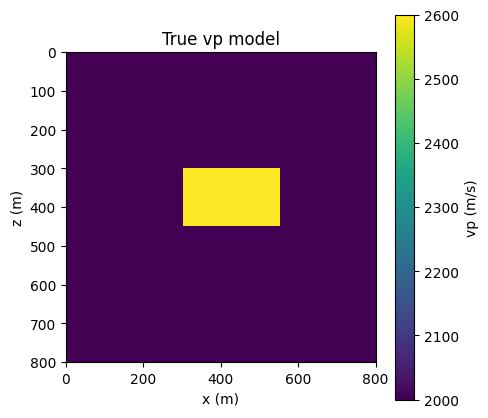

In [8]:
nz, nx = N

def flatten(arr_zx):
    """(NZ, NX) numpy array -> flat tensor in the engine's internal
    (NX, NZ)-C-order layout (see the note above)."""
    return torch.from_numpy(arr_zx.T.ravel())

def unflatten(flat, dtype=np.float32):
    """Inverse of flatten(): flat array/tensor -> (NZ, NX) numpy array."""
    if isinstance(flat, torch.Tensor):
        flat = flat.detach().numpy()
    return flat.reshape(nx, nz).T.astype(dtype)

vp_true = np.full((nz, nx), 2000.0, dtype=np.float32)
vs_true = np.full((nz, nx), 1200.0, dtype=np.float32)
rho_true = np.full((nz, nx), 2000.0, dtype=np.float32)

# A higher-velocity rectangular anomaly
vp_true[30:45, 30:55] = 2600.0
vs_true[30:45, 30:55] = 1560.0

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(vp_true, cmap="viridis", extent=[0, nx * dh, nz * dh, 0])
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.set_title("True vp model")
fig.colorbar(im, ax=ax, label="vp (m/s)")
plt.show()


## 4. Source and receivers

Geometry is passed as plain tensors, matching `SeisCL.py`'s own `src_pos_all`/`rec_pos_all`/`src_all` conventions:

- `src_pos`: shape `[allns, 5]`, columns `[sx, sy, sz, srcid, src_type]` (`sy=0` in 2D).
- `rec_pos`: shape `[allng, 8]`, columns `[gx, gy, gz, srcid, recid, -, -, -]`.
- `src`: shape `[allns, NT]`, one wavelet row per source.

Use `src_type=0` (inject directly into `vx`) -- `SeisCL.py`'s default acquisition helpers use `src_type=100`, a "backward compatibility" convention (`src/automatic_kernels.c`) that injects into a derived field instead and isn't what this binding's plain per-name convention expects.

We place one source above the anomaly and a line of receivers below it, so the direct arrival at the receivers nearest the anomaly is delayed relative to its neighbors -- a small transmission-tomography experiment.

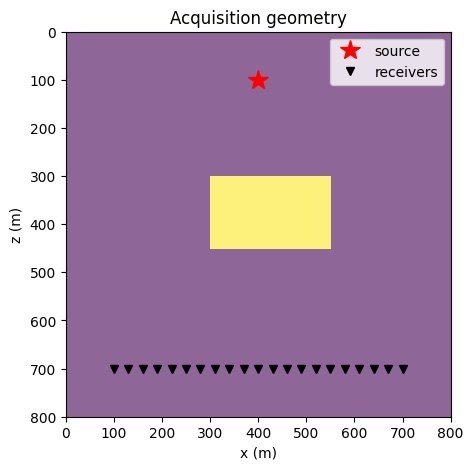

In [9]:
src_pos = torch.tensor([[400.0, 0.0, 100.0, 0.0, 0.0]], dtype=torch.float32)

n_rec = 21
rec_x = np.linspace(100.0, 700.0, n_rec)
rec_pos = torch.zeros((n_rec, 8), dtype=torch.float32)
rec_pos[:, 0] = torch.from_numpy(rec_x.astype(np.float32))
rec_pos[:, 2] = 700.0
rec_pos[:, 4] = torch.arange(1, n_rec + 1)

t = np.arange(NT) * dt
f0 = 15.0
t0 = 1.0 / f0
ricker = ((1 - 2 * (np.pi * f0 * (t - t0)) ** 2)
          * np.exp(-((np.pi * f0 * (t - t0)) ** 2)))
src = torch.from_numpy(ricker.astype(np.float32)).reshape(1, NT)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(vp_true, cmap="viridis", extent=[0, nx * dh, nz * dh, 0],
               alpha=0.6)
ax.plot(src_pos[:, 0], src_pos[:, 2], "r*", markersize=15, label="source")
ax.plot(rec_pos[:, 0], rec_pos[:, 2], "kv", markersize=6, label="receivers")
ax.set_xlabel("x (m)")
ax.set_ylabel("z (m)")
ax.legend()
ax.set_title("Acquisition geometry")
plt.show()


## 5. Forward modeling

`seiscl_forward(cfg, params, src, src_pos, rec_pos, output_fields=...)` runs the forward simulation and returns a dict of `[allng, NT]` seismogram tensors, one per requested field. No `requires_grad` is set here, so this is a plain (non-differentiable, cheaper) forward pass.

In [10]:
true_params = {
    "M": flatten(vp_true),
    "mu": flatten(vs_true),
    "rho": flatten(rho_true),
}

data_obs = seiscl_forward(cfg, true_params, src, src_pos, rec_pos,
                          output_fields=["vx"])["vx"]
print("data_obs shape:", tuple(data_obs.shape))  # [allng, NT]


data_obs shape: (21, 900)


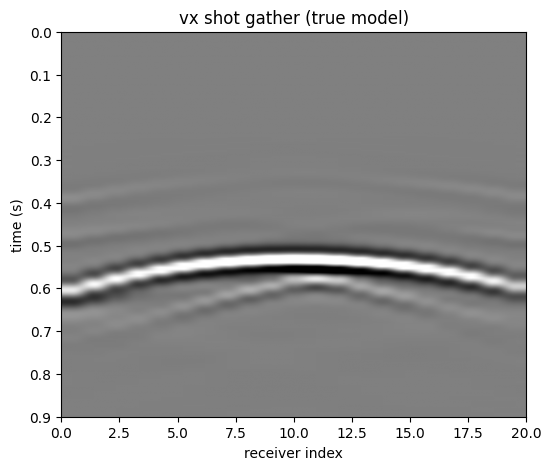

In [11]:
fig, ax = plt.subplots(figsize=(6, 5))
clip = data_obs.abs().max() * 0.5
im = ax.imshow(data_obs.numpy().T, cmap="gray", aspect="auto",
               vmin=-clip, vmax=clip,
               extent=[0, n_rec - 1, NT * dt, 0])
ax.set_xlabel("receiver index")
ax.set_ylabel("time (s)")
ax.set_title("vx shot gather (true model)")
plt.show()


## 6. Gradients with `torch.autograd`

This is what sets `SeisCL.torch` apart from the plain `SeisCL` class: setting `requires_grad=True` on a parameter tensor and calling `.backward()` on a loss computed from the modeled data runs SeisCL's adjoint pass and returns the gradient through ordinary PyTorch autograd -- the same interface as any other differentiable PyTorch operation, no manual adjoint-source bookkeeping required.

Internally, `forward()` writes a small temporary checkpoint (the engine's existing boundary-wavefield storage, reused across two calls instead of one subprocess-per-call) and `backward()` reads it back to compute the gradient without recomputing the forward pass -- see `SeisCL/torch/op.py`'s module docstring for details. This is transparent to the caller.

To illustrate this, we invert for `vp` starting from a homogeneous initial guess (no anomaly), using the mismatch against the `data_obs` computed above as a toy loss -- exactly the first gradient computation of an FWI iteration.

In [14]:
vp_init = np.full((nz, nx), 2000.0, dtype=np.float32)  # no anomaly

M_init = flatten(vp_init).requires_grad_(True)
mu_fixed = flatten(vs_true)
rho_fixed = flatten(rho_true)

data_init = seiscl_forward(cfg, {"M": M_init, "mu": mu_fixed, "rho": rho_fixed},
                           src, src_pos, rec_pos, output_fields=["vx"])["vx"]

loss = 0.5 * ((data_init - data_obs.detach()) ** 2).sum()
loss.backward()

print("loss:", loss.item())
print("grad_M nonzero elements:", int((M_init.grad != 0).sum()))


loss: 4.0087805075472716e-08
grad_M nonzero elements: 6400


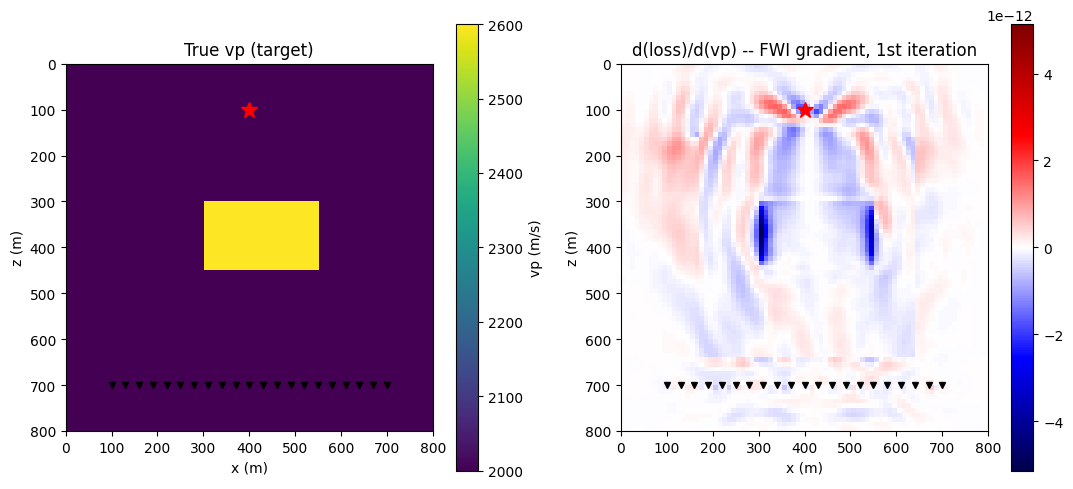

In [15]:
grad_vp = unflatten(M_init.grad)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
im0 = axes[0].imshow(vp_true, cmap="viridis", extent=[0, nx * dh, nz * dh, 0])
axes[0].set_title("True vp (target)")
fig.colorbar(im0, ax=axes[0], label="vp (m/s)")

vmax = np.abs(grad_vp).max()
im1 = axes[1].imshow(grad_vp, cmap="seismic", extent=[0, nx * dh, nz * dh, 0],
                     vmin=-vmax, vmax=vmax)
axes[1].set_title("d(loss)/d(vp) -- FWI gradient, 1st iteration")
fig.colorbar(im1, ax=axes[1])

for ax in axes:
    ax.plot(src_pos[:, 0], src_pos[:, 2], "r*", markersize=12)
    ax.plot(rec_pos[:, 0], rec_pos[:, 2], "kv", markersize=4)
    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")
plt.tight_layout()
plt.show()


The gradient highlights the anomaly's location: gradient-descent updates to `vp` in that region are exactly what would reduce the mismatch against `data_obs` on the next iteration. A real FWI loop would wrap the last two cells in a `torch.optim` step and repeat for many iterations -- see `SeisCL/tests/test_torch_binding.py`'s `test_gradient_finite_difference` for a numerical check of this gradient against a central finite difference.

## Current limitations

- CUDA only, and CPU-side (host) tensors only for now -- passing a `.cuda()` tensor is not yet supported (a future extension would accept GPU tensors directly via their device pointer, avoiding the host round-trip).
- Only `cfg.BACK_PROP_TYPE = 1` (boundary-storage gradient) is supported; the DFT/frequency-domain method (`BACK_PROP_TYPE = 2`) isn't wired up yet.
- Gradients are returned only for material parameters (`M`/`mu`/`rho`/...); source-wavelet gradients (`cfg.GRADSRCOUT`) aren't computed by the current binding.
- One process, one GPU group -- no multi-GPU domain decomposition or MPI, by design (see `SeisCL/torch/bindings.cpp`'s file header).